# OpenDataSUS — Catálogo de Dados Abertos do SUS

This notebook demonstrates the **`opendatasus`** accessor for the [Portal de Dados Abertos do SUS](https://dadosabertos.saude.gov.br/) — the open-data catalog of the Brazilian Ministry of Health.

The accessor lets you:

- **List & search** all datasets in the catalog (filter by theme, tag and resource format);
- **Fetch full metadata** (CKAN package) for any dataset;
- **List resources** and **download** data files (CSV, JSON, PDF, ...) to disk.

> **Note:** this accessor covers the *whole CKAN catalog*. For querying the structured
> DEMAS REST API (`apidadosabertos.saude.gov.br/v1`), see the
> [`demas` accessor notebook](33_DEMAS_Dados_Abertos_SUS.ipynb); for DATASUS system
> files, see the [`datasus` accessor](01_pysus_brazilian_health_data.ipynb).

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import zipfile

from epidatasets.sources.opendatasus import OpenDataSUSAccessor

pd.set_option("display.max_colwidth", 60)

acc = OpenDataSUSAccessor()  # caches under ~/.cache/epi_data/opendatasus
print(acc)

OpenDataSUS — the catalog of the Brazilian Ministry of Health open-data portal (dadosabertos.saude.gov.br): list all datasets, fetch their metadata and download their data resources. (https://dadosabertos.saude.gov.br/)


In [2]:
info = acc.info()
info

{'name': 'opendatasus',
 'description': 'OpenDataSUS — the catalog of the Brazilian Ministry of Health open-data portal (dadosabertos.saude.gov.br): list all datasets, fetch their metadata and download their data resources.',
 'url': 'https://dadosabertos.saude.gov.br/',
 'class': 'OpenDataSUSAccessor'}

The portal publishes **Brazilian national data**, which is reflected in `list_countries()`:

In [3]:
acc.list_countries()

,country_code,country_name
0,BR,Brazil


## 1. Exploring the catalog: themes (groups)

Datasets are organized in **themes** (`groups` in CKAN terminology):

In [4]:
groups = acc.list_groups()
groups

,name,display_name
0,arboviroses,Arboviroses
1,assistencia-a-saude,Assistência à saúde
2,assistencia-farmaceutica,Assistência Farmacêutica
3,atencao-primaria,Atenção Primária
4,ciencia-tecnologia,Ciência & Tecnologia
5,diagnosticos-e-tratamentos,Diagnósticos e Tratamentos
6,economia-da-saude,Economia da Saúde
7,educacao-em-saude,Educação em Saúde
8,indicadores-de-saude,Indicadores de saúde
9,prevencao-e-promocao-da-saude,Prevenção e Promoção da Saúde


## 2. Searching datasets

Free-text search works with Portuguese terms (the catalog is in Portuguese). Let's search for **"dengue"**:

In [5]:
dengue = acc.list_datasets(q="dengue")
dengue[["name", "title", "formats", "groups"]]

,name,title,formats,groups
0,arboviroses-dengue,Sinan/Dengue,"PDF, API, CSV, JSON, XML",Arboviroses
1,siasi_modulo_morbidades_dados_arboviroses,Sistema de Informação da Atenção à Saúde Indígena (Siasi...,"PDF, CSV, JSON, XML",Saúde Indígena
2,ripsa-morbidade-dimensao-2-taxa-de-incidencia-de-doencas...,[RIPSA] Morbidade - Dimensão 2: Taxa de incidência de do...,"CSV, JSON, XML",
3,arboviroses-febre-de-chikungunya,Sinan/Febre de Chikungunya,"PDF, API, CSV, JSON, XML",Arboviroses
4,arboviroses-zika-virus,Sinan/Vírus Zika,"PDF, API, CSV, JSON, XML",Arboviroses


We can also filter by theme — e.g. all datasets in the *Arboviroses* group:

In [6]:
arbo = acc.list_datasets(group="arboviroses")
arbo[["name", "title", "formats"]]

,name,title,formats
0,arboviroses-dengue,Sinan/Dengue,"PDF, API, CSV, JSON, XML"
1,arboviroses-febre-de-chikungunya,Sinan/Febre de Chikungunya,"PDF, API, CSV, JSON, XML"
2,arboviroses-zika-virus,Sinan/Vírus Zika,"PDF, API, CSV, JSON, XML"
3,febre-amarela-em-humanos-e-primatas-nao-humanos,Febre Amarela em humanos e primatas não-humanos - 1994 a...,"PDF, API, CSV, JSON, XML"


### Full catalog listing

`list_datasets_all()` pages through the whole catalog (20 rows per page).
Here we cap it at 3 pages for speed — remove `max_pages` to get everything:

In [7]:
catalog = acc.list_datasets_all(max_pages=3)
print(f"{len(catalog)} datasets fetched")
catalog[["name", "title", "groups"]].head(10)

Reached max_pages=3; results may be incomplete.


60 datasets fetched


,name,title,groups
0,tuberculose_sesai,Sistema de Informação da Atenção à Saúde Indígena (Siasi...,Saúde Indígena
1,siasi_banco_obitos,Sistema de Informação da Atenção à Saúde Indígena (Siasi...,Saúde Indígena
2,bps,Banco de Preços em Saúde - BPS,Economia da Saúde
3,srag-2019-a-2026,Banco de dados da Síndrome Respiratória Aguda Grave (SRA...,Vigilância e Meio Ambiente
4,sisagua-controle-mensal-infraestrutura-operacional,SISAGUA - Controle Mensal - Infraestrutura Operacional,Vigilância e Meio Ambiente
5,sisagua-controle-mensal-amostras-fora-do-padrao,SISAGUA - Controle mensal - Amostras fora do padrão,Vigilância e Meio Ambiente
6,sisagua-controle-mensal-demais-parametros,SISAGUA - Controle mensal - demais parâmetros,Vigilância e Meio Ambiente
7,sisagua-controle-mensal-parametros-basicos,SISAGUA - Controle Mensal - Parâmetros básicos,Vigilância e Meio Ambiente
8,registro-de-ocupacao-hospitalar-covid-19,Registro de Ocupação Hospitalar COVID-19,Assistência à saúde
9,macrorregiao-de-saude,Macrorregião e Região de Saúde,Indicadores de saúde


## 3. Dataset metadata

`get_dataset_metadata()` returns the full CKAN package as a tidy
`field`/`value` DataFrame — organization, license, dates, tags, extras…:

In [8]:
meta = acc.get_dataset_metadata("arboviroses-dengue")
meta

,field,value
0,author,Coordenação-Geral de Vigilância de Arboviroses – CGARB/D...
1,author_email,
2,creator_user_id,8a38bdca-8601-4d5e-a3e4-f463c6f8ff09
3,id,4d5e5d44-58a8-4d67-b8aa-4ef1e4b00a1c
4,isopen,True
5,license_id,cc-by
6,license_title,Creative Commons Atribuição
7,license_url,http://www.opendefinition.org/licenses/cc-by
8,maintainer,
9,maintainer_email,


## 4. Resources (downloadable files)

Each dataset exposes **resources**: the actual data files. Let's see which
formats are available for the dengue dataset:

In [9]:
resources = acc.get_resources("arboviroses-dengue")
print(f"{len(resources)} resources")
resources["format"].value_counts()

83 resources


format
CSV     27
XML     27
JSON    27
PDF      1
API      1
Name: count, dtype: int64

In [10]:
csvs = resources[resources["format"].str.upper() == "CSV"].copy()
csvs["year"] = csvs["name"].str.extract(r"(\d{4})")
csvs[["name", "year", "url", "size"]].sort_values("year").tail(6)

,name,year,url,size
7,Dengue - 2021,2021,https://s3.sa-east-1.amazonaws.com/ckan.saude.gov.br/SIN...,NaN
6,Dengue - 2022,2022,https://s3.sa-east-1.amazonaws.com/ckan.saude.gov.br/SIN...,NaN
5,Dengue - 2023,2023,https://s3.sa-east-1.amazonaws.com/ckan.saude.gov.br/SIN...,NaN
4,Dengue - 2024,2024,https://s3.sa-east-1.amazonaws.com/ckan.saude.gov.br/SIN...,NaN
3,Dengue - 2025,2025,https://s3.sa-east-1.amazonaws.com/ckan.saude.gov.br/SIN...,NaN
2,Dengue - 2026,2026,https://s3.sa-east-1.amazonaws.com/ckan.saude.gov.br/SIN...,NaN


## 5. Downloading data

`download_resource()` streams a single file to disk (selected by `resource_id`
or `name`), while `download_dataset()` grabs every downloadable resource at
once. Resources with format `API` (documentation links) are skipped
automatically.

We'll download the **Dengue year-2000 CSV** — one of the smallest files:

In [11]:
path = acc.download_resource(
    "arboviroses-dengue",
    name="Dengue - 2000",
)
print(path)

/home/fccoelho/.cache/epi_data/opendatasus/downloads/arboviroses-dengue/Dengue - 2000.csv


## 6. Loading the data with pandas

The file is a ZIP archive containing a latin-1 encoded CSV with the
notification records (SINAN dictionaries apply):

In [12]:
with zipfile.ZipFile(path) as z:
    inner = z.namelist()[0]
    print("inside the archive:", inner)
    with z.open(inner) as f:
        df = pd.read_csv(f, encoding="latin-1", low_memory=False)

print(f"{len(df):,} records, {df.shape[1]} columns")
df[["DT_NOTIFIC", "SG_UF_NOT", "MUNICIPIO", "NU_IDADE", "CS_SEXO"]].head()

inside the archive: DENGBR00.csv
172,855 records, 107 columns


,DT_NOTIFIC,SG_UF_NOT,MUNICIPIO,NU_IDADE,CS_SEXO
0,2000-12-09,AC,NaN,A046,M
1,2000-04-14,AC,NaN,A023,M
2,2000-04-10,AC,NaN,A020,M
3,2000-09-21,AC,NaN,A030,F
4,2000-12-04,AC,NaN,A008,F


A quick look at the **top-10 municipalities** by number of notifications:

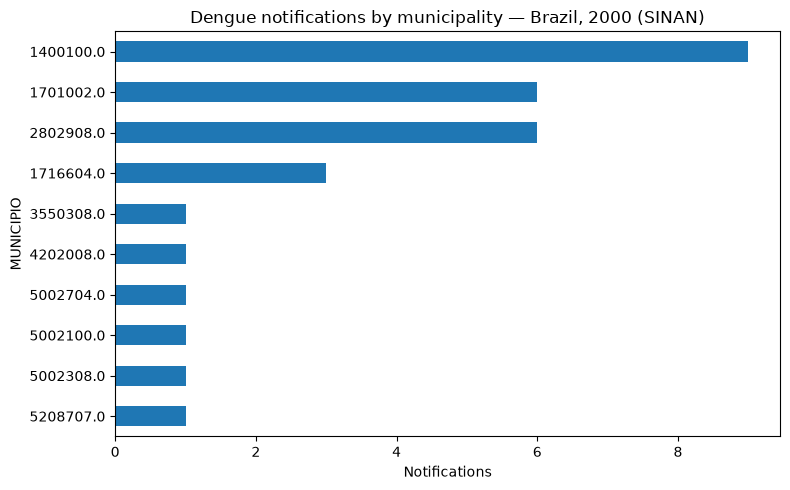

In [13]:
top = df["MUNICIPIO"].value_counts().head(10)

fig, ax = plt.subplots(figsize=(8, 5))
top.sort_values().plot(kind="barh", ax=ax, color="#1f77b4")
ax.set_xlabel("Notifications")
ax.set_title("Dengue notifications by municipality — Brazil, 2000 (SINAN)")
fig.tight_layout()
plt.show()

## 7. Using the registry

Like every epidatasets source, the accessor is discoverable through the
plugin registry:

In [14]:
from epidatasets import get_source, list_sources

print("opendatasus" in list_sources())
acc2 = get_source("opendatasus")
acc2.list_datasets(q="covid", fmt="CSV")[["name", "title"]]

INFO:epidatasets.sources.eurostat:eurostat library not installed. Using REST API fallback.
INFO:epidatasets.sources.opendatasus:Loading cached data: /home/fccoelho/.cache/epi_data/opendatasus/dadosabertos.saude.gov.br__next_data_jz8vv6uzmw1zju9y02mX2_dataset.json_page-1_q-covid_res_format-CSV.json


True


,name,title
0,registro-de-ocupacao-hospitalar-covid-19,Registro de Ocupação Hospitalar COVID-19
1,covid-19-vacinacao,Campanha Nacional de Vacinação contra Covid-19
2,distribuicao-de-equipamentos-de-protecao-individual-e-in...,Distribuição de Equipamentos de Proteção Individual e In...
3,tecnologias-e-diretrizes-para-tratamento-e-prevencao-da-...,Tecnologias e Diretrizes para tratamento e prevenção da ...
4,siasi_plataforma_bi_covid19,Plataforma das Emergências em Saúde Indígena – Plataform...
5,indicadores-de-enfrentamento-e-monitoramento-a-covid-19-...,Saúde Indígena - Indicadores de enfrentamento e monitora...
6,srag-2019-a-2026,Banco de dados da Síndrome Respiratória Aguda Grave (SRA...
7,srag-2009-2012,SRAG 2009 a 2012 - Banco de Dados de Síndroma Respiratór...
8,srag-2013-2018,SRAG 2013 a 2018 - Banco de Dados de Síndrome Respiratór...
9,notificacoes-de-sindrome-gripal-leve-2024,Notificações de Síndrome Gripal - 2024


## Summary

- `list_datasets()` / `list_datasets_all()` — browse & search the catalog;
- `list_groups()` / `list_tags()` — catalog facets;
- `get_dataset()` / `get_dataset_metadata()` — full CKAN package metadata;
- `get_resources()` — the downloadable files of a dataset;
- `download_resource()` / `download_dataset()` — stream files to disk.

**References**

- Portal: https://dadosabertos.saude.gov.br/
- API docs (DEMAS): https://apidadosabertos.saude.gov.br/v1/
- Issue: fccoelho/epidemiological-datasets#84